In [1]:
pip install pandas pyarrow s3fs scikit-learn xgboost shap matplotlib seaborn

/bin/bash: switchml: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `switchml'
/bin/bash: module: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `module'
Note: you may need to restart the kernel to use updated packages.


## Load Loan-Level Dataset

We load the snapshot dataset created in Athena.

Unlike the earlier panel dataset (many rows per loan), this dataset contains
**one row per loan**. Each row represents the loan characteristics at origination
and a target variable indicating whether the loan defaulted within the
prediction horizon.

This structure is standard for mortgage PD models and avoids the issue of
duplicate loan-month observations with identical features.

In [53]:
import pandas as pd

path = "s3://freddie-mac-mortgage-risk/analytics/loan_snapshot_pd/"

df = pd.read_parquet(path)

print(df.shape)
df.head()

(1285429, 9)


,loan_sequence_number,credit_score,original_ltv,original_dti,original_interest_rate,original_upb,number_of_borrowers,property_state,default_next_12m
0,F18Q30153417,793,92,43,4.875,205000,1,MO,0
1,F18Q30188165,739,90,38,4.875,114000,1,NJ,0
2,F18Q30188182,719,80,37,5.000,139000,1,KY,0
3,F18Q30188285,786,34,39,4.625,150000,2,TN,0
4,F18Q30188294,763,56,43,4.990,175000,1,MO,0


BASIC CLEANING : REPLACE MISSING INDICATORS

In [54]:
df = df.replace({999: None, 9999: None})

DROP REMAINING NULLS

In [55]:
df = df.dropna()

In [56]:
df.shape

(1271880, 9)

## Define Features and Target Variable

In this step we define the input variables (features) used to predict mortgage default risk.

These variables capture borrower risk, loan structure, and loan seasoning effects.

**Features used:**
- Credit score
- Loan-to-value ratio
- Debt-to-income ratio
- Interest rate
- Loan age
- Remaining loan maturity
- Number of borrowers

**Target variable:**

`default_next_12m`

This indicates whether the loan defaults within the next 12 months.

In [62]:
X = df[[
    "credit_score",
    "original_ltv",
    "original_dti",
    "original_interest_rate",
    "original_upb",
    "number_of_borrowers"
]]

y = df["default_next_12m"].astype(int)

## Train-Test Split

We split the dataset into training and testing samples.

Since this dataset contains one observation per loan, we use a simple random
split to evaluate model performance.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

SGDClassifier uses gradient-based optimization, which requires features to
have similar scales.

We standardize the features using StandardScaler so that each variable has
mean 0 and variance 1.

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Probability of Default Model

We train a logistic regression model using SGDClassifier.

SGDClassifier is chosen because it scales efficiently to large datasets while
approximating logistic regression.

Key configuration choices:

- `loss="log_loss"` implements logistic regression.
- `penalty="l2"` adds regularization to prevent overfitting.
- `class_weight="balanced"` compensates for the low default rate.
- `verbose=1` prints optimization progress during training.

In [65]:
from sklearn.linear_model import SGDClassifier
import time

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    max_iter=2000,
    learning_rate="optimal",
    class_weight="balanced",
    verbose=1,
    random_state=42
)

start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print("Training time:", round(end - start,2),"seconds")

-- Epoch 1
Norm: 1.17, NNZs: 6, Bias: -0.327441, T: 1017504, Avg. loss: 0.953586
Total training time: 0.19 seconds.
-- Epoch 2
Norm: 1.09, NNZs: 6, Bias: -0.429525, T: 2035008, Avg. loss: 0.616456
Total training time: 0.37 seconds.
-- Epoch 3
Norm: 1.05, NNZs: 6, Bias: -0.495172, T: 3052512, Avg. loss: 0.610717
Total training time: 0.56 seconds.
-- Epoch 4
Norm: 0.84, NNZs: 6, Bias: -0.427011, T: 4070016, Avg. loss: 0.608789
Total training time: 0.75 seconds.
-- Epoch 5
Norm: 0.92, NNZs: 6, Bias: -0.429308, T: 5087520, Avg. loss: 0.607583
Total training time: 0.94 seconds.
-- Epoch 6
Norm: 0.88, NNZs: 6, Bias: -0.348390, T: 6105024, Avg. loss: 0.606881
Total training time: 1.12 seconds.
-- Epoch 7
Norm: 0.84, NNZs: 6, Bias: -0.458302, T: 7122528, Avg. loss: 0.606411
Total training time: 1.31 seconds.
-- Epoch 8
Norm: 0.84, NNZs: 6, Bias: -0.335653, T: 8140032, Avg. loss: 0.605904
Total training time: 1.49 seconds.
-- Epoch 9
Norm: 0.88, NNZs: 6, Bias: -0.357245, T: 9157536, Avg. loss: 

## Model Evaluation

We evaluate model performance using ROC-AUC.

ROC-AUC measures the model's ability to rank loans by default risk. A value
close to 0.5 indicates random predictions, while values above 0.7 indicate
good discrimination.

Mortgage PD models typically achieve ROC-AUC values between 0.65 and 0.75.

In [66]:
from sklearn.metrics import roc_auc_score

pred = model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, pred)

print("ROC AUC:", auc)

ROC AUC: 0.7424193569991847


0.74 denotes good discrimination ability

## ROC Curve

The ROC curve visualizes the trade-off between true positive rate and false
positive rate across different probability thresholds.

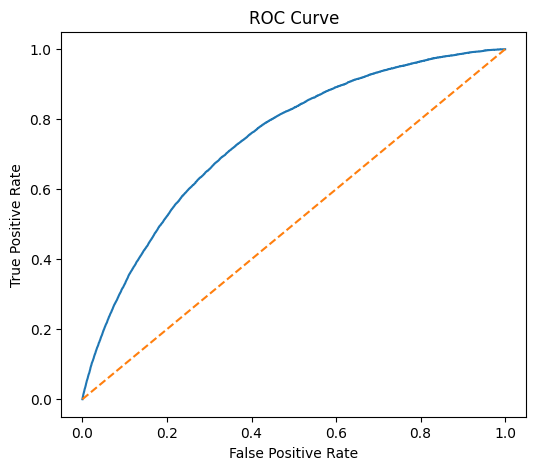

In [69]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, pred)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Model Interpretation

To understand which variables drive default risk, we inspect the model
coefficients.

In logistic regression models, the magnitude of coefficients indicates
the strength of each variable's relationship with default probability.

In [70]:
import pandas as pd

importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

importance

original_dti              0.453956
original_ltv              0.198477
original_upb              0.159048
original_interest_rate    0.109590
number_of_borrowers      -0.338491
credit_score             -0.720819
dtype: float64

## Feature Importance Visualization

This plot shows which borrower and loan characteristics contribute most
to default risk predictions.

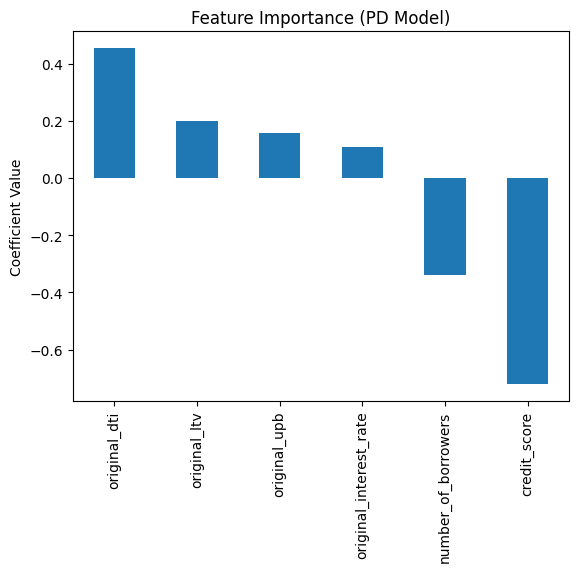

In [71]:
import matplotlib.pyplot as plt

importance.plot(kind="bar")

plt.title("Feature Importance (PD Model)")
plt.ylabel("Coefficient Value")
plt.show()

- **Debt-to-Income (DTI)** has the strongest positive relationship with default.
- **Loan-to-Value (LTV)** also increases default risk, reflecting borrower leverage.
- **Credit score** has the strongest negative coefficient, indicating that higher
  borrower credit quality reduces default probability.
- **Number of borrowers** shows a negative relationship with default risk,
  suggesting loans with multiple borrowers may have more stable repayment capacity.

  The calibration plot indicates that higher predicted PD buckets correspond
to higher observed default rates, suggesting that the model provides
reasonable probability estimates. Hence, feature signs are economically correct.

## Expected Loss Estimation

Credit risk models are typically used to estimate portfolio losses.

Expected Loss is calculated as:

EL = PD × LGD × EAD

Where:
- PD = Probability of Default
- LGD = Loss Given Default
- EAD = Exposure at Default

In [72]:
df["pd"] = model.predict_proba(
    scaler.transform(X)
)[:,1]

LGD = 0.35

df["expected_loss"] = df["pd"] * LGD * df["original_upb"]

df["expected_loss"].sum()

np.float64(44655224213.93402)

## 44.6 Billion USD Expected Loss

In [79]:
# Actual Total Loan Porftolio Amount

df["original_upb"].sum()

np.int64(296880953000)

## Total Portfolio Loan Amount = 296 Billion USD

In [80]:
df["pd"].mean()

np.float64(0.41606545402160244)

## Probability Calibration Note

The average predicted probability of default **(~41%)** is significantly higher
than the observed default rate **(~1.3%)**.

This occurs because the model was trained with **class balancing** to handle the
strong class imbalance in mortgage defaults.

Class balancing improves the model’s ability to distinguish between risky and
safe loans (discriminatory power), but it distorts the absolute probability
scale.

Therefore the predicted probabilities should be interpreted as **relative risk
scores rather than calibrated default probabilities**.

In production credit risk systems, probability calibration techniques such as
**Platt scaling** or **isotonic regression** are typically applied to correct this.

## Portfolio Risk Segmentation by Credit Score

We analyze expected loss across credit score buckets to understand
how risk varies across borrower quality segments.

Credit score is one of the strongest predictors of mortgage default risk.
Lower credit score segments typically exhibit higher default probability
and therefore contribute disproportionately to expected losses.

This segmentation allows lenders to identify which borrower groups drive
portfolio credit risk.

In [81]:
fico_loss = (
    df.assign(
        fico_bucket=pd.cut(
            df["credit_score"],
            bins=[300,650,700,750,800,850],
            labels=["300-650","650-700","700-750","750-800","800-850"]
        )
    )
    .groupby("fico_bucket")["expected_loss"]
    .sum()
    .div(1e9)
    .round(2)
    .rename("Expected Loss (USD Billions)")
)

fico_loss

/tmp/ipykernel_39583/2311577278.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("fico_bucket")["expected_loss"]


fico_bucket
300-650     2.15
650-700     9.41
700-750    16.35
750-800    14.51
800-850     2.24
Name: Expected Loss (USD Billions), dtype: float64

Key observations from the analysis:

- **Mid-credit segments (700–800 FICO)** contribute the largest portion of
  expected losses because they represent a large share of the loan portfolio.
- **Lower credit score borrowers (<650)** exhibit higher individual default
  risk but represent a smaller portion of the portfolio exposure.
- **Higher credit score borrowers (>800)** contribute relatively little to
  expected losses due to lower default probability.

## Kolmogorov-Smirnov (KS) Statistic

The KS statistic measures the maximum separation between the cumulative
distributions of predicted probabilities for defaulted and non-defaulted loans.

In credit risk modelling, KS is commonly used to evaluate the discriminatory
power of a PD model.

In [75]:
import numpy as np

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, pred)

ks = np.max(tpr - fpr)

print("KS Statistic:", ks)

KS Statistic: 0.36245989525012434


Typical KS ranges for credit models:

| KS | Interpretation |
|----|---------------|
| <0.20 | Weak model |
| 0.20 – 0.30 | Acceptable |
| 0.30 – 0.45 | Good |
| >0.45 | Strong model |

The model achieves a KS statistic of approximately **0.36**, indicating good
separation between defaulting and performing loans.

## PD Calibration Plot

Probability of Default Calibration

Calibration evaluates whether predicted default probabilities align with
observed default rates.

Loans are grouped into probability buckets, and the average predicted
probability is compared with the observed default frequency.

A well-calibrated model shows a close relationship between predicted and
observed default rates.

/tmp/ipykernel_39583/459725734.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df_test.groupby("pd_bucket").agg({


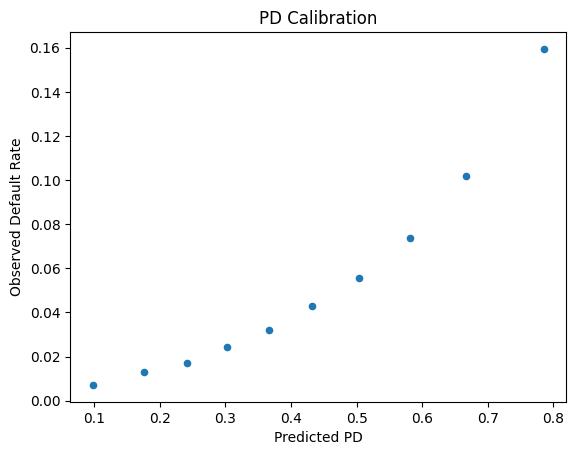

In [76]:
df_test = X_test.copy()
df_test["pd"] = pred
df_test["actual"] = y_test.values

df_test["pd_bucket"] = pd.qcut(df_test["pd"], 10)

calibration = df_test.groupby("pd_bucket").agg({
    "pd":"mean",
    "actual":"mean"
})

calibration.plot(x="pd", y="actual", kind="scatter")
plt.xlabel("Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("PD Calibration")
plt.show()

The calibration plot indicates that higher predicted PD buckets correspond
to higher observed default rates, suggesting that the model provides
reasonable probability estimates.

Calibration is also Monotonic

## Portfolio Delinquency Trend

Delinquency trends show how the proportion of loans in different delinquency
states evolves over time.

In mortgage portfolios, loans typically transition through delinquency stages
such as:

- Current
- 30 days past due
- 60 days past due
- 90+ days past due (default stage)

In [84]:
trend = pd.read_parquet(
    "s3://freddie-mac-mortgage-risk/analytics/delinquency_trends/"
)

trend

,monthly_reporting_period,total_loans,dpd_30_plus,dpd_60_plus,dpd_90_plus
0,201801,631,0,0,0
1,201802,75157,0,0,0
2,201803,160989,354,0,0
3,201804,278365,682,36,0
4,201805,393566,1018,65,11
...,...,...,...,...,...
88,202505,268059,8492,4103,2904
89,202506,266151,8644,4085,2817
90,202507,264261,8279,3981,2746
91,202508,262362,8609,3954,2708


## Portfolio Delinquency Trend

This chart tracks the evolution of delinquency levels in the mortgage
portfolio over time.

The analysis focuses on three delinquency stages:

- **30+ days past due (DPD)** — early delinquency indicator
- **60+ days past due** — elevated borrower distress
- **90+ days past due** — severe delinquency and potential default

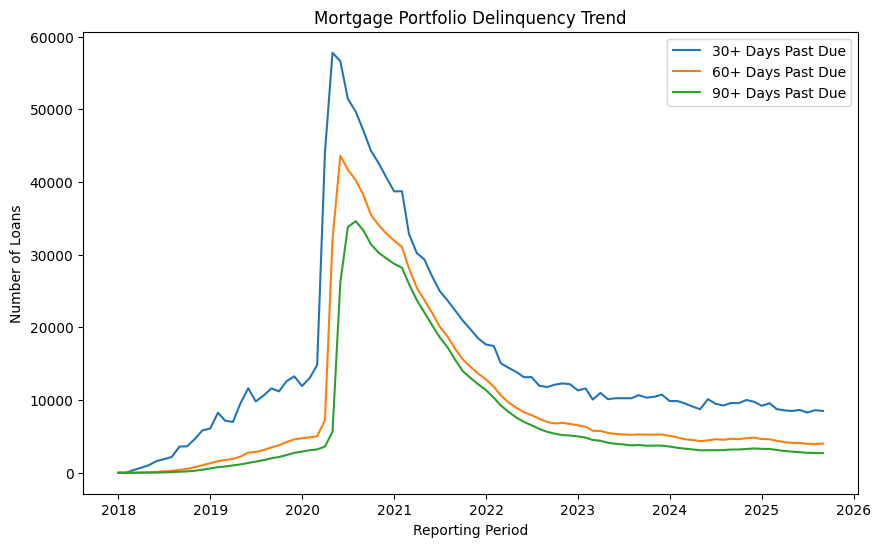

In [87]:
# Convert YYYYMM to proper date
trend["date"] = pd.to_datetime(trend["monthly_reporting_period"].astype(str), format="%Y%m")

# Plot delinquency trends
plt.figure(figsize=(10,6))

plt.plot(trend["date"], trend["dpd_30_plus"], label="30+ Days Past Due")
plt.plot(trend["date"], trend["dpd_60_plus"], label="60+ Days Past Due")
plt.plot(trend["date"], trend["dpd_90_plus"], label="90+ Days Past Due")

plt.title("Mortgage Portfolio Delinquency Trend")
plt.xlabel("Reporting Period")
plt.ylabel("Number of Loans")
plt.legend()

plt.show()

2018–2019: Low and Stable Delinquencies. This reflects a healthy mortgage market. The US economy was strong during this period.

2020 Spike — This is the COVID Shock. 2020 Spike — This is the COVID Shock

2021–2023 Decline: After the spike, delinquency falls sharply. US mortgage relief programs such as forbearance programs, loan modifications and stimulus payments

helped borrowers recover.

2024–2025 Stabilization: Credit risk normalized after the pandemic shock.

Ordering is Correct : 30+ DPD > 60+ DPD > 90+ DPD

## Delinquency Migration Matrix

A migration matrix shows how loans transition between delinquency states
between consecutive reporting periods.

Each cell represents the probability of a loan moving from one delinquency
state to another.

Example:-

- Current → Current (loan remains performing)
- Current → 30 DPD (borrower becomes delinquent)
- 30 DPD → 60 DPD (risk escalation)
- 90+ DPD → Default

Migration analysis is widely used in credit risk management to understand
portfolio dynamics and to build transition-based risk models.

In [92]:
migration = pd.read_parquet(
    "s3://freddie-mac-mortgage-risk/analytics/migration_matrix/"
)

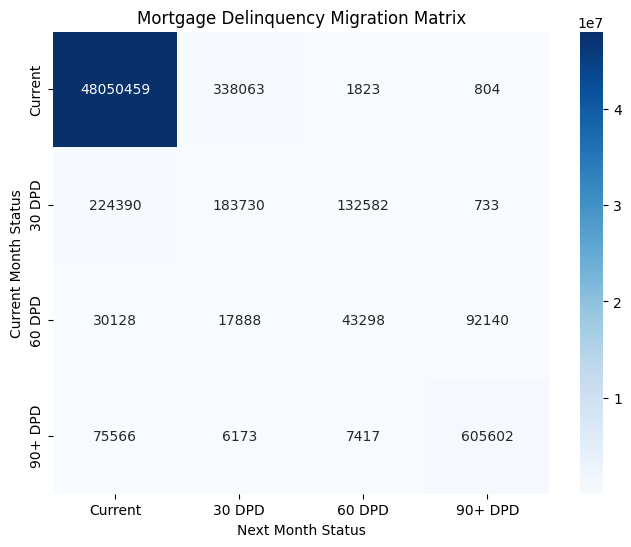

In [93]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Collapse delinquency states
migration["current_bucket"] = np.where(migration["current_status"] >= 3, 3, migration["current_status"])
migration["next_bucket"] = np.where(migration["next_status"] >= 3, 3, migration["next_status"])

migration_clean = migration.dropna(subset=["current_bucket","next_bucket"])

migration_matrix = migration_clean.pivot_table(
    index="current_bucket",
    columns="next_bucket",
    values="transition_count",
    aggfunc="sum"
)

# Rename labels
labels = {
    0: "Current",
    1: "30 DPD",
    2: "60 DPD",
    3: "90+ DPD"
}

migration_matrix.rename(index=labels, columns=labels, inplace=True)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    migration_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Mortgage Delinquency Migration Matrix")
plt.xlabel("Next Month Status")
plt.ylabel("Current Month Status")

plt.show()

### Key Observations

The migration matrix highlights several important credit risk dynamics
within the mortgage portfolio.

- Most loans remain **Current**, indicating a stable performing portfolio.
  i.e. Current → Current ≈ 48M
- A portion of current loans transition to **30 days past due**, representing
early signs of borrower financial stress.
  i.e. Current → 30DPD ≈ 338k
- Loans in **30-day delinquency** have a meaningful probability of curing and
returning to current status.
  i.e. Current → 30DPD ≈ 338k
  i.e. 30DPD → Current ≈ 224k

- As loans progress to deeper delinquency stages (60 or 90+ days past due),
the likelihood of curing decreases and the probability of remaining
delinquent increases.
  e.g. 30 DPD to 60 DPD ≈ 132k
             Versus
  60 DPD to 30 DPD ≈ 17k  OR
  60 DPD to Current ≈ 30k 


## Project Summary

This project builds an end-to-end mortgage credit risk analytics pipeline
using the Freddie Mac Single-Family Loan Dataset.

**Dataset**
- ~1.2M mortgage loans
- ~$297B total loan exposure

**Data Engineering**
- AWS S3 + Athena pipeline for large-scale loan performance data
- Construction of loan-level modelling dataset

**Portfolio Risk Analytics**
- Delinquency trend analysis (2018–2025)
- Delinquency migration matrix
- Risk segmentation by borrower credit score

**Probability of Default Model**
- Logistic regression (SGD)
- ROC-AUC: **0.74**
- KS Statistic: **0.36**

**Credit Risk Framework**
- Expected Loss calculation: **PD × LGD × EAD**
- Portfolio exposure analysed by borrower risk segments

This workflow demonstrates how large mortgage datasets can be used to
build scalable credit risk analytics and probability of default models.